In [1]:
import pandas as pd
df = pd.read_csv('shipment_delay_data.csv')

In [3]:
df.head()

,shipment_id,distance_km,weather,vehicle_type,vendor_rating,delay_days
0,SHP001,100.66,Rain,Ship,2,1.32
1,SHP002,89.14,Fog,Air,1,2.12
2,SHP003,89.47,Storm,Train,5,0.98
3,SHP004,100.18,Storm,Air,2,1.27
4,SHP005,111.29,Storm,Air,1,0.08


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   shipment_id    50 non-null     object 
 1   distance_km    50 non-null     float64
 2   weather        50 non-null     object 
 3   vehicle_type   50 non-null     object 
 4   vendor_rating  50 non-null     int64  
 5   delay_days     50 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 2.5+ KB


In [5]:
df.isnull().sum()

shipment_id      0
distance_km      0
weather          0
vehicle_type     0
vendor_rating    0
delay_days       0
dtype: int64

In [6]:
df = df.drop('shipment_id', axis=1)

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

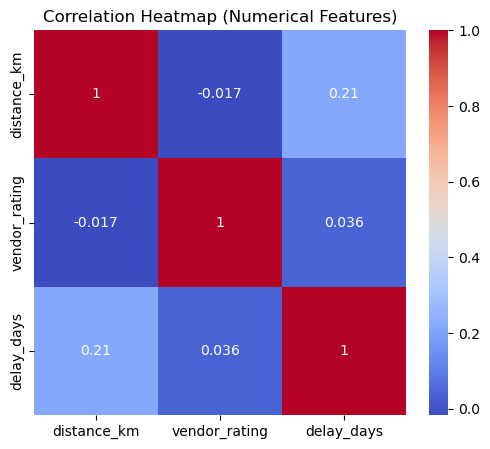

In [47]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

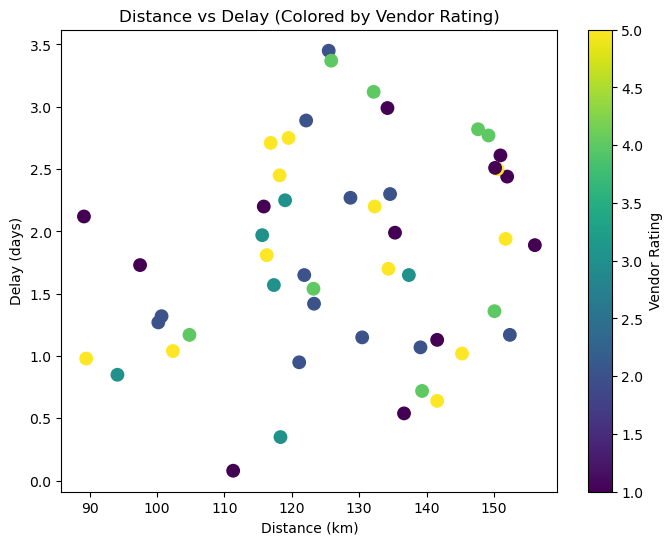

In [48]:
plt.figure(figsize=(8, 6))
plt.scatter(df['distance_km'], df['delay_days'], c=df['vendor_rating'], cmap='viridis', s=80)
plt.colorbar(label='Vendor Rating')
plt.title('Distance vs Delay (Colored by Vendor Rating)')
plt.xlabel('Distance (km)')
plt.ylabel('Delay (days)')
plt.show()

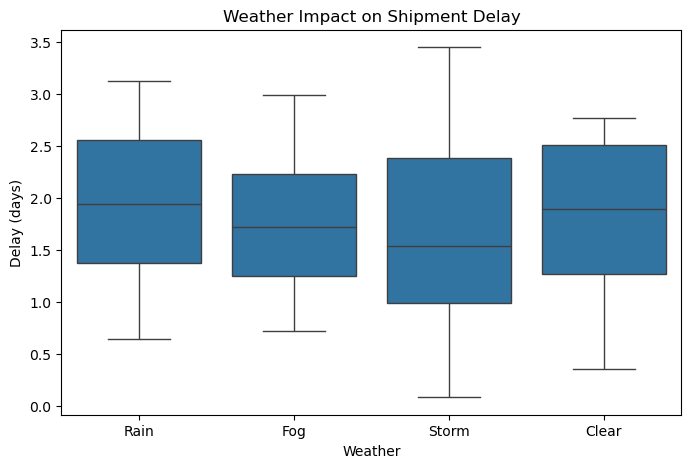

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='weather', y='delay_days', data=df)
plt.title('Weather Impact on Shipment Delay')
plt.xlabel('Weather')
plt.ylabel('Delay (days)')
plt.show()

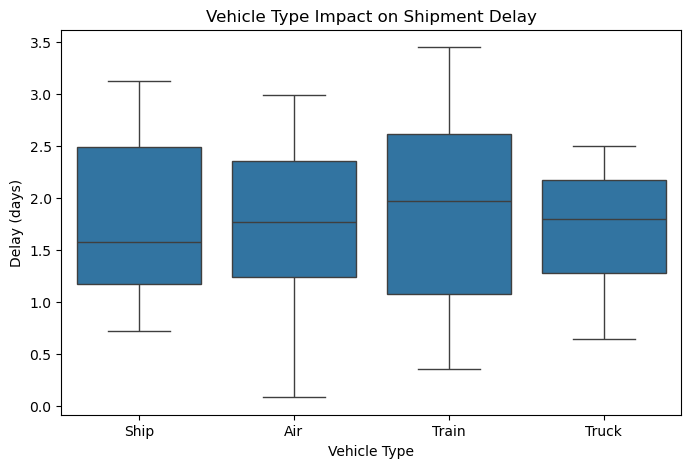

In [50]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='vehicle_type', y='delay_days', data=df)
plt.title('Vehicle Type Impact on Shipment Delay')
plt.xlabel('Vehicle Type')
plt.ylabel('Delay (days)')
plt.show()

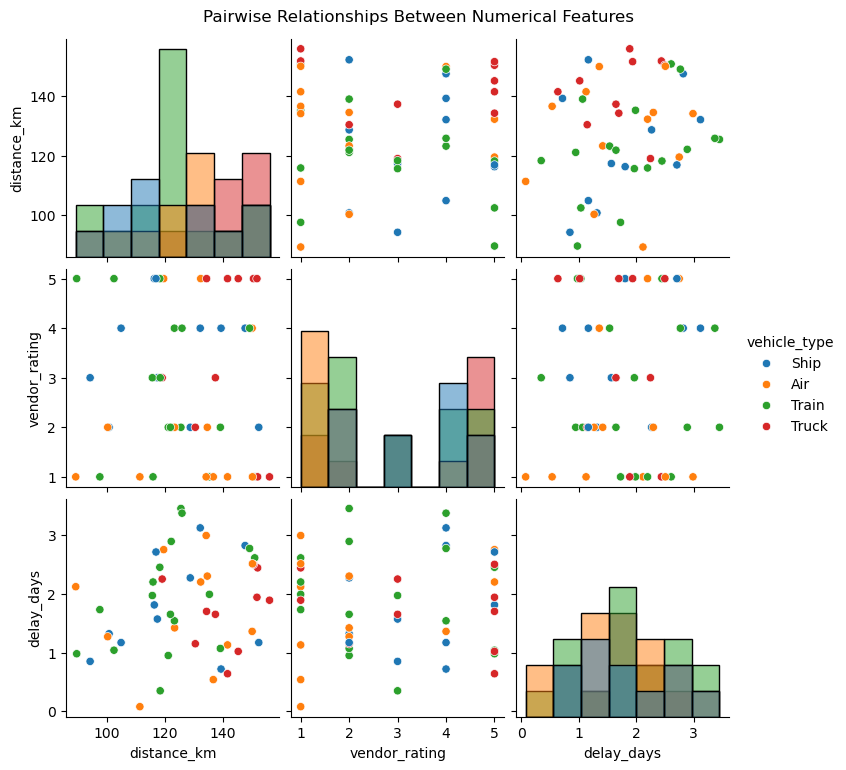

In [51]:
sns.pairplot(df, vars=['distance_km', 'vendor_rating', 'delay_days'], hue='vehicle_type', diag_kind='hist')
plt.suptitle('Pairwise Relationships Between Numerical Features', y=1.02)
plt.show()

In [7]:
categorical_features = ['weather', 'vehicle_type']
numerical_features = ['distance_km', 'vendor_rating']
target = 'delay_days'

In [60]:
X = df.drop(target, axis=1)
y = df[target]

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [10]:
numerical_transformer = SimpleImputer(strategy='mean')

In [11]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [15]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['distance_km',
                                                   'vendor_rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['weather',
                                                   'vehicle_type'])])),
                ('regressor', LinearRegression())])

In [19]:
y_pred = model.predict(X_test)

In [20]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

In [34]:
covariance_matrix = df[numerical_features].cov()
print(covariance_matrix)

               distance_km  vendor_rating
distance_km     324.594262      -0.471478
vendor_rating    -0.471478       2.360816


In [35]:
variance = df[numerical_features].var()
print(variance)

distance_km      324.594262
vendor_rating      2.360816
dtype: float64


<Axes: >

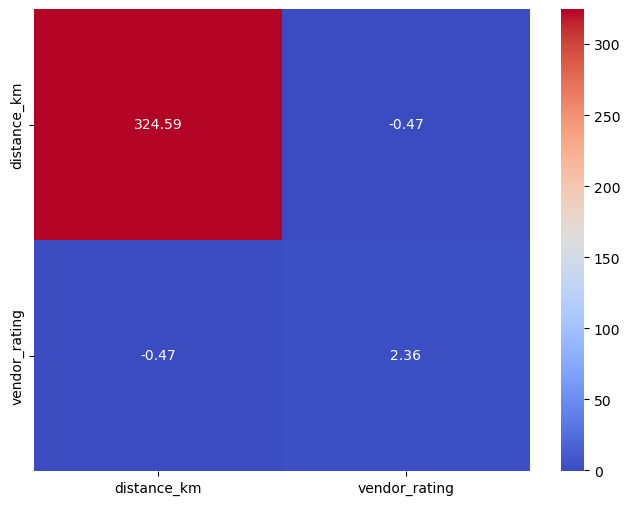

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(covariance_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=numerical_features, yticklabels=numerical_features)

In [38]:
df1=df.copy()

In [39]:
df1['weather_vehicle'] = df1['weather'] + '_' + df1['vehicle_type']

In [65]:
X = df1.drop(target, axis=1)
y = df1[target]

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
categorical_features = ['weather_vehicle']
numerical_features = ['distance_km', 'vendor_rating']
target = 'delay_days'

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
numerical_transformer = SimpleImputer(strategy='mean')

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [ ]:
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}
    },
    'Ridge': {
        'model': Ridge(random_state=42),
        'params': {
            'regressor__alpha': [0.1, 1.0, 10.0, 50.0]
        }
    },
    'Lasso': {
        'model': Lasso(random_state=42, max_iter=10000),
        'params': {
            'regressor__alpha': [0.01, 0.1, 1.0, 10.0]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [50, 100],
            'regressor__max_depth': [None, 10],
            'regressor__min_samples_leaf': [2, 4]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [50, 100],
            'regressor__learning_rate': [0.01, 0.1],
            'regressor__max_depth': [3, 5]
        }
    },
    'Support Vector Regressor (SVR)': {
        'model': SVR(),
        'params': {
            'regressor__C': [0.1, 1, 10],
            'regressor__kernel': ['linear', 'rbf']
        }
    }
}

In [75]:
model_results = {}

In [ ]:
for model_name, config in models.items():
    
    print(f"\nTraining {model_name}...")
    
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', config['model'])
    ])
    
    
    if not config['params']:
        pipeline.fit(X_train, y_train)
        best_model = pipeline
    else:
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=config['params'],
            cv=3,
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    y_pred = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    model_results[model_name] = mae
    print(f"MAE for {model_name}: {mae:.4f}")
for model_name, mae in model_results.items():
    print(f"{model_name}: {mae:.4f}")


Training Linear Regression...
MAE for Linear Regression: 1.0147

Training Ridge...
Best parameters for Ridge: {'regressor__alpha': 50.0}
MAE for Ridge: 0.7582

Training Lasso...
Best parameters for Lasso: {'regressor__alpha': 1.0}
MAE for Lasso: 0.7585

Training Random Forest...
Best parameters for Random Forest: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 4, 'regressor__n_estimators': 50}
MAE for Random Forest: 0.7417

Training Gradient Boosting...
Best parameters for Gradient Boosting: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 100}
MAE for Gradient Boosting: 0.8382

Training Support Vector Regressor (SVR)...
Best parameters for Support Vector Regressor (SVR): {'regressor__C': 10, 'regressor__kernel': 'rbf'}
MAE for Support Vector Regressor (SVR): 0.7699

--- Final Model Comparison (MAE) ---
Linear Regression: 1.0147
Ridge: 0.7582
Lasso: 0.7585
Random Forest: 0.7417
Gradient Boosting: 0.8382
Support Vector Regressor (SV

In [77]:
y_pred = best_model.predict(X_test)

In [78]:
mae = mean_absolute_error(y_test, y_pred)

In [83]:
y_pred

array([1.73763771, 2.04382954, 2.04985311, 2.04060606, 1.83563556,
       2.0327399 , 1.8174017 , 1.94572653, 1.86857637, 2.00623243])

In [84]:
mae

0.7698714775126971